In [1]:
import pandas as pd
import numpy as np
import seaborn as sns

In [2]:
df=pd.read_csv('data.csv')
df.head()

,User ID,Gender,Age,EstimatedSalary,Purchased
0,15624510,Male,19,19000,0
1,15810944,Male,35,20000,0
2,15668575,Female,26,43000,0
3,15603246,Female,27,57000,0
4,15804002,Male,19,76000,0


In [3]:
df.isna().sum()

User ID            0
Gender             0
Age                0
EstimatedSalary    0
Purchased          0
dtype: int64

In [4]:
df.dtypes


User ID            int64
Gender               str
Age                int64
EstimatedSalary    int64
Purchased          int64
dtype: object

In [6]:

df['Gender']=df['Gender'].map({'Male':1,'Female':0})

In [25]:
df.head()
df['Gender']=df['Gender'].astype(int)
df.dtypes
df=df.astype(float)

In [26]:
df.dtypes

Gender             float64
Age                float64
EstimatedSalary    float64
Purchased          float64
dtype: object

In [27]:
df=df.drop('User ID',axis=1)

KeyError: "['User ID'] not found in axis"

In [28]:
df.head()

,Gender,Age,EstimatedSalary,Purchased
0,1.0,19.0,19000.0,0.0
1,1.0,35.0,20000.0,0.0
2,0.0,26.0,43000.0,0.0
3,0.0,27.0,57000.0,0.0
4,1.0,19.0,76000.0,0.0


<Axes: >

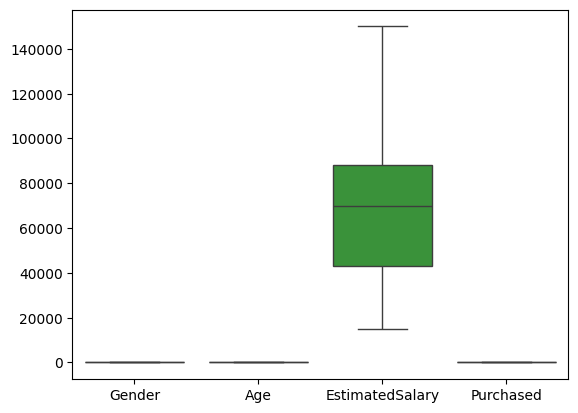

In [29]:
sns.boxplot(data=df)

In [36]:
class logistic_reg:
    def __init__(self,learning_rate=0.01,epoch=1000):
        self.lr=learning_rate
        self.epoch=epoch
        self.bias=None
        self.weights=None

    def sigmoid(self,z):
        z=np.clip(z,-250,250)
        return 1/(1+np.exp(-z))

    def fit(self,X,y):
        n_sample,n_feature=X.shape
        self.weights=np.zeros(n_feature)
        self.bias=0
        for _ in range(self.epoch):
            y_linear=np.dot(X,self.weights)+self.bias
            y_pred =self.sigmoid(y_linear)
            error=y_pred-y
            dw=np.dot(error,X)/n_sample
            db=np.mean(error)
            self.weights-=self.lr*dw
            self.bias-=self.lr*db
    def predict(self,X):
        y_predict_linear=np.dot(X,self.weights)+self.bias
        y_predicted=self.sigmoid(y_predict_linear)
        y_predicted_cls=[1 if p>0.5 else 0 for p in y_predicted]
        return np.array(y_predicted_cls)
        

In [37]:
model=logistic_reg(learning_rate=0.01 , epoch=1000)
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()

X=df.drop('Purchased',axis=1)
y=df['Purchased']
X_train,X_test,Y_train,y_test=train_test_split(X,y,test_size=0.2)
X_train_scaled=scaler.fit_transform(X_train)
X_test_scaled=scaler.transform(X_test)

In [38]:
model.fit(X_train_scaled,Y_train)


In [39]:
y_predict=model.predict(X_test_scaled)

In [44]:
from sklearn.metrics import confusion_matrix,accuracy_score,precision_score,recall_score
cm=confusion_matrix(y_test,y_predict)
TN, FP, FN, TP=cm.ravel()
accuracy = accuracy_score(y_test, y_predict)
error_rate = 1 - accuracy
precision = precision_score(y_test, y_predict)
recall = recall_score(y_test, y_predict)

print("Confusion Matrix:")
print(cm)
print(f"\nAccuracy: {accuracy}")
print(f"Error Rate: {error_rate}")

Confusion Matrix:
[[41  4]
 [11 24]]

Accuracy: 0.8125
Error Rate: 0.1875


In [45]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
X=df[['Age','EstimatedSalary','Gender']].values
y=df['Purchased'].values
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)
scaler=StandardScaler()
X_train=scaler.fit_transform(X_train)
X_test=scaler.transform(X_test)
from sklearn.linear_model import LogisticRegression
model=LogisticRegression()
model.fit(X_train,y_train)
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score
y_pred=model.predict(X_test)
cm = confusion_matrix(y_test, y_pred)
TN, FP, FN, TP = cm.ravel()
# 8. Calculate Me++trics
accuracy = accuracy_score(y_test, y_pred)
error_rate = 1 - accuracy
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)

print("Confusion Matrix:")
print(cm)
print(f"\nAccuracy: {accuracy}")
print(f"Error Rate: {error_rate}")

KeyError: "['Gender_Male'] not in index"